In [5]:
import numpy as np
import pandas as pd

# ====== SCENARIO INPUTS ======

true_rate_A = 0.20
true_rate_B = 0.215   # expected lift

daily_apps_A = 150
daily_apps_B = 150

max_days = 14

# Decision thresholds (same as monitoring notebook)
prob_threshold = 0.95
loss_threshold = 0.001

# Simulation settings
num_simulations = 200

np.random.seed(42)

In [6]:
def run_single_experiment():

    cum_apps_A = 0
    cum_apps_B = 0
    cum_book_A = 0
    cum_book_B = 0

    for day in range(1, max_days + 1):

        bookings_A = np.random.binomial(daily_apps_A, true_rate_A)
        bookings_B = np.random.binomial(daily_apps_B, true_rate_B)

        cum_apps_A += daily_apps_A
        cum_apps_B += daily_apps_B
        cum_book_A += bookings_A
        cum_book_B += bookings_B

        # Closed-form posterior
        alpha_A = 1 + cum_book_A
        beta_A  = 1 + (cum_apps_A - cum_book_A)

        alpha_B = 1 + cum_book_B
        beta_B  = 1 + (cum_apps_B - cum_book_B)

        samples = 20000

        p_A = np.random.beta(alpha_A, beta_A, samples)
        p_B = np.random.beta(alpha_B, beta_B, samples)

        prob_B_better = np.mean(p_B > p_A)

        loss_if_A = np.mean(np.maximum(p_B - p_A, 0))
        loss_if_B = np.mean(np.maximum(p_A - p_B, 0))

        expected_loss = min(loss_if_A, loss_if_B)

        # Decision condition
        if prob_B_better > prob_threshold and expected_loss < loss_threshold:
            return day

    return max_days  # no early decision

In [7]:
decision_days = []

for _ in range(num_simulations):
    d = run_single_experiment()
    decision_days.append(d)

sim_df = pd.DataFrame({"decision_day": decision_days})

In [8]:
sim_df

,decision_day
0,2
1,14
2,14
3,9
4,14
...,...
195,3
196,14
197,2
198,14


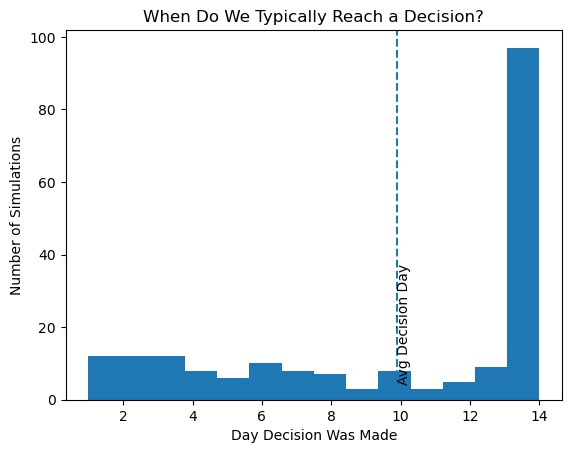

In [9]:
import matplotlib.pyplot as plt

plt.figure()

plt.hist(sim_df["decision_day"], bins=max_days)

plt.xlabel("Day Decision Was Made")
plt.ylabel("Number of Simulations")
plt.title("When Do We Typically Reach a Decision?")

plt.axvline(sim_df["decision_day"].mean(), linestyle='--')
plt.text(sim_df["decision_day"].mean(), 5, "Avg Decision Day", rotation=90)

plt.show()